# Final Corpus EDA

Descriptive statistics and visualisations for the thesis **Data** chapter.  
Works exclusively on the outlet-specific `*_clean.csv` files produced by notebooks 01–08.

**Outputs:**
- Corpus-overview table (outlet × key statistics)
- Article-count bar chart by outlet
- Monthly publication-volume chart
- Article-length distributions (violin plots)

All figures are saved as PDF to `figures/` for direct LaTeX inclusion.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path

# ── Paths ──
BASE = Path("/Users/MattisHaumann/Dev/Thesis/data preprocessing")
FIG_DIR = BASE / "figures"
TABLE_DIR = BASE / "tables"
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

# ── Global academic plot style ──
plt.rcParams.update({
    "font.family":        "serif",
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.15,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linestyle":     "--",
})

# ── Outlet metadata (ordered: mainstream → right-populist → right-wing → pro-Russian) ──
OUTLET_META = {
    "Tagesschau":         {"file": "tagesschau_clean.csv",  "cat": "Mainstream"},
    "NIUS":               {"file": "nius_clean.csv",        "cat": "Right-Populist"},
    "Tichys Einblick":    {"file": "tichys_clean.csv",      "cat": "Right-Populist"},
    "Compact":            {"file": "compact_clean.csv",     "cat": "Right-Wing"},
    "Deutschland-Kurier": {"file": "dkurier_clean.csv",     "cat": "Right-Wing"},
    "RT DE":              {"file": "rt_de_clean.csv",       "cat": "Pro-Russian"},
    "Anti-Spiegel":       {"file": "antispiegel_clean.csv", "cat": "Pro-Russian"},
}

# Colorblind-friendly palette (ColorBrewer Dark2)
PALETTE = {
    "Tagesschau":         "#1B9E77",
    "NIUS":               "#D95F02",
    "Tichys Einblick":    "#7570B3",
    "Compact":            "#E7298A",
    "Deutschland-Kurier": "#66A61E",
    "RT DE":              "#E6AB02",
    "Anti-Spiegel":       "#A6761D",
}

OUTLET_ORDER = list(OUTLET_META.keys())
COLORS = [PALETTE[o] for o in OUTLET_ORDER]

## 1  Data Loading

In [2]:
frames = []
for name, meta in OUTLET_META.items():
    path = BASE / meta["file"]
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], utc=True, format="mixed").dt.tz_localize(None)
    df["outlet"] = name
    df["category"] = meta["cat"]
    frames.append(df)
    print(f"{name:25s}  {len(df):>6,} articles  ({meta['file']})")

corpus = pd.concat(frames, ignore_index=True)

# Derived columns
corpus["word_count"] = corpus["Text"].fillna("").str.split().str.len()
corpus["char_count"] = corpus["Text"].fillna("").str.len()
corpus["year_month"] = corpus["Date"].dt.to_period("M")

print(f"\n{'Total':25s}  {len(corpus):>6,} articles")
print(f"Date range: {corpus['Date'].min().date()} to {corpus['Date'].max().date()}")

Tagesschau                  6,320 articles  (tagesschau_clean.csv)
NIUS                        3,269 articles  (nius_clean.csv)
Tichys Einblick             2,756 articles  (tichys_clean.csv)
Compact                     1,486 articles  (compact_clean.csv)
Deutschland-Kurier          1,484 articles  (dkurier_clean.csv)
RT DE                       4,560 articles  (rt_de_clean.csv)
Anti-Spiegel                  565 articles  (antispiegel_clean.csv)

Total                      20,440 articles
Date range: 2025-07-31 to 2026-01-31


## 2  Corpus Overview

Summary table for the thesis Data chapter.

In [3]:
overview = (
    corpus.groupby("outlet", sort=False)
    .agg(
        Category=("category", "first"),
        Articles=("word_count", "size"),
        From=("Date", "min"),
        To=("Date", "max"),
        Mean_Words=("word_count", "mean"),
        Median_Words=("word_count", "median"),
        Std_Words=("word_count", "std"),
    )
)
overview["From"] = overview["From"].dt.date
overview["To"]   = overview["To"].dt.date
for c in ["Mean_Words", "Median_Words", "Std_Words"]:
    overview[c] = overview[c].round(0).astype(int)

# Totals row
totals = pd.DataFrame({
    "Category": [""],
    "Articles": [len(corpus)],
    "From": [corpus["Date"].min().date()],
    "To": [corpus["Date"].max().date()],
    "Mean_Words": [int(corpus["word_count"].mean())],
    "Median_Words": [int(corpus["word_count"].median())],
    "Std_Words": [int(corpus["word_count"].std())],
}, index=["Total"])

overview_full = pd.concat([overview, totals])
display(overview_full)

overview_full.to_csv(TABLE_DIR / "corpus_overview.csv")
print(f"Saved → {TABLE_DIR / 'corpus_overview.csv'}")

,Category,Articles,From,To,Mean_Words,Median_Words,Std_Words
Tagesschau,Mainstream,6320,2025-07-31,2026-01-30,601,524,427
NIUS,Right-Populist,3269,2025-08-01,2026-01-31,561,418,508
Tichys Einblick,Right-Populist,2756,2025-08-01,2026-01-31,876,800,524
Compact,Right-Wing,1486,2025-08-01,2026-01-31,448,404,450
Deutschland-Kurier,Right-Wing,1484,2025-08-01,2026-01-31,214,148,229
RT DE,Pro-Russian,4560,2025-08-01,2026-01-19,583,422,410
Anti-Spiegel,Pro-Russian,565,2025-08-01,2026-01-31,1446,1363,793
Total,,20440,2025-07-31,2026-01-31,611,485,500


Saved → /Users/MattisHaumann/Dev/Thesis/data preprocessing/tables/corpus_overview.csv


## 3  Corpus Composition

Saved → /Users/MattisHaumann/Dev/Thesis/data preprocessing/figures/corpus_composition.pdf


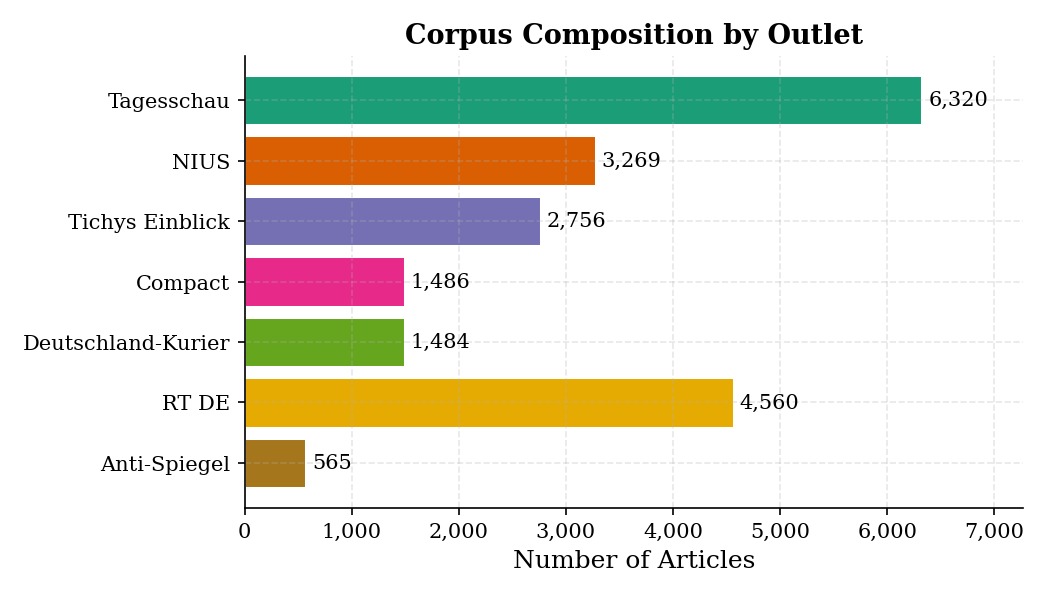

In [4]:
counts = corpus.groupby("outlet", sort=False).size().reindex(OUTLET_ORDER)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(counts.index, counts.values, color=COLORS, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left", fontsize=10)

ax.set_xlabel("Number of Articles")
ax.set_title("Corpus Composition by Outlet")
ax.invert_yaxis()
ax.set_xlim(0, max(counts) * 1.15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.tight_layout()
fig.savefig(FIG_DIR / "corpus_composition.pdf")
print(f"Saved → {FIG_DIR / 'corpus_composition.pdf'}")
plt.show()

## 4  Monthly Publication Volume

Saved → /Users/MattisHaumann/Dev/Thesis/data preprocessing/figures/monthly_volume.pdf


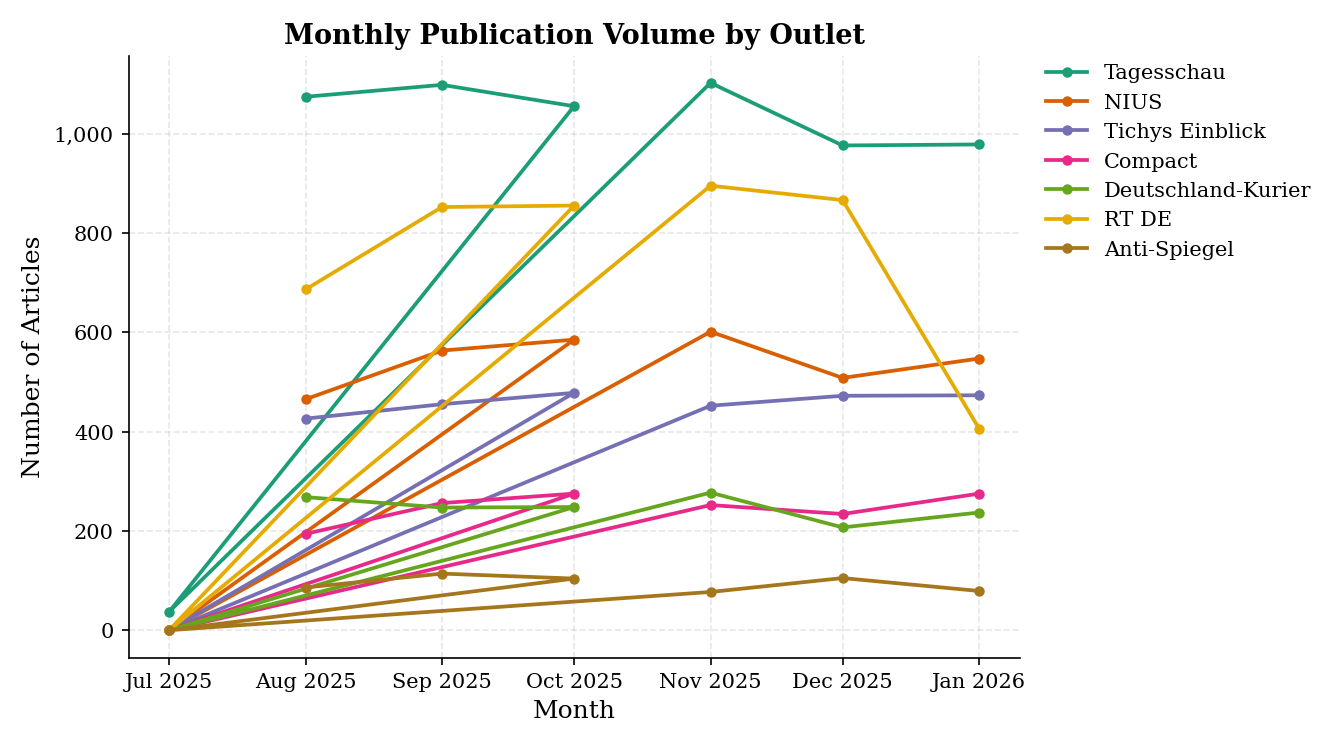

In [5]:
monthly = (
    corpus.groupby(["year_month", "outlet"], sort=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=OUTLET_ORDER)
)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(9, 5))
for outlet in OUTLET_ORDER:
    ax.plot(monthly.index, monthly[outlet], marker="o", markersize=4,
            label=outlet, color=PALETTE[outlet], linewidth=1.8)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Articles")
ax.set_title("Monthly Publication Volume by Outlet")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_volume.pdf")
print(f"Saved → {FIG_DIR / 'monthly_volume.pdf'}")
plt.show()

## 5  Article-Length Distributions

Violin plots of word counts per outlet. Clipped at the 99th percentile for readability.

Saved → /Users/MattisHaumann/Dev/Thesis/data preprocessing/figures/article_length_distributions.pdf


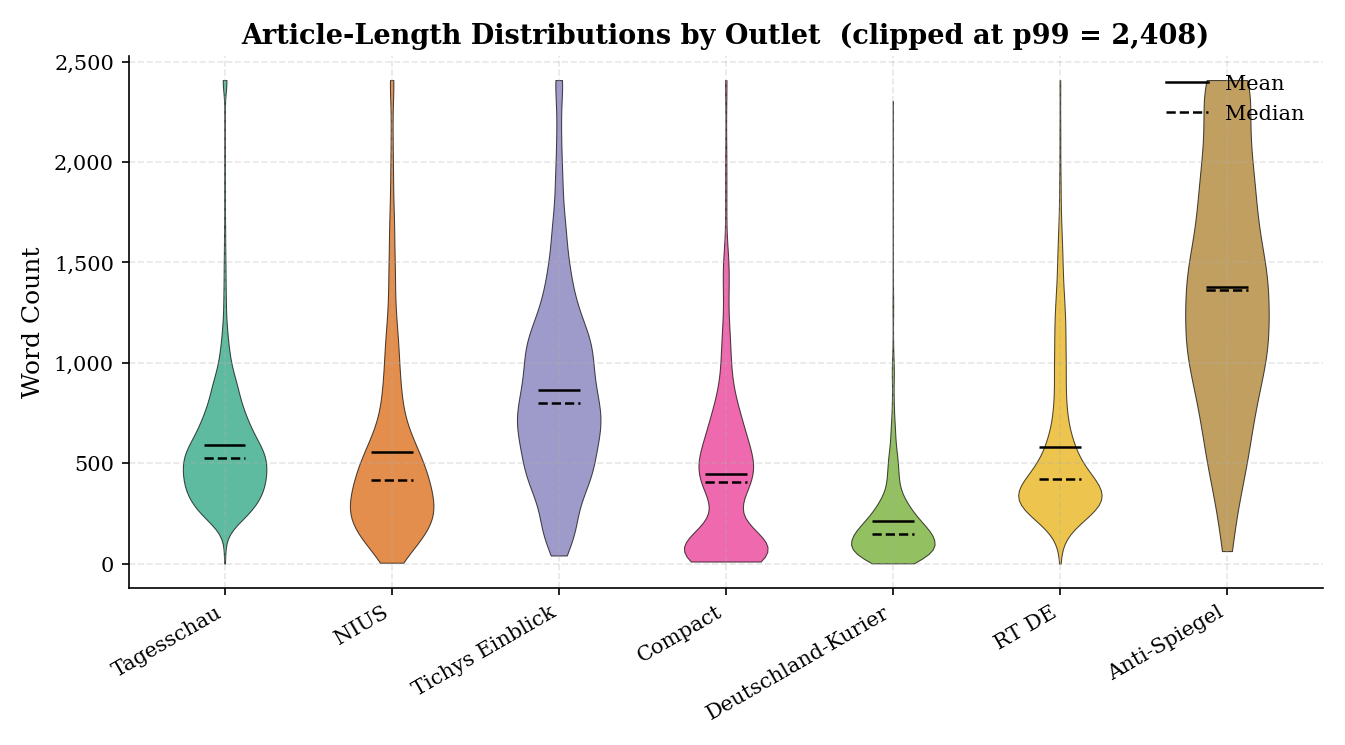

In [6]:
p99 = corpus["word_count"].quantile(0.99)
plot_df = corpus[["outlet", "word_count"]].copy()
plot_df["wc_clipped"] = plot_df["word_count"].clip(upper=p99)

fig, ax = plt.subplots(figsize=(9, 5))
parts = ax.violinplot(
    [plot_df.loc[plot_df["outlet"] == o, "wc_clipped"].values for o in OUTLET_ORDER],
    positions=range(len(OUTLET_ORDER)),
    showmeans=True, showmedians=True, showextrema=False,
)

for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(COLORS[i])
    body.set_alpha(0.7)
    body.set_edgecolor("black")
    body.set_linewidth(0.5)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linewidth(1.2)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(1.2)
parts["cmedians"].set_linestyle("--")

ax.set_xticks(range(len(OUTLET_ORDER)))
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")
ax.set_ylabel("Word Count")
ax.set_title(f"Article-Length Distributions by Outlet  (clipped at p99 = {int(p99):,})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

legend_elems = [
    Line2D([0], [0], color="black", lw=1.2, label="Mean"),
    Line2D([0], [0], color="black", lw=1.2, ls="--", label="Median"),
]
ax.legend(handles=legend_elems, loc="upper right", frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "article_length_distributions.pdf")
print(f"Saved → {FIG_DIR / 'article_length_distributions.pdf'}")
plt.show()

## 6  Detailed Length Statistics

In [7]:
length_stats = (
    corpus.groupby("outlet", sort=False)["word_count"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .reindex(OUTLET_ORDER)
    .round(0).astype(int)
)
length_stats.columns = ["N", "Mean", "Std", "Min", "p5", "p25", "Median", "p75", "p95", "Max"]

display(length_stats)

length_stats.to_csv(TABLE_DIR / "article_length_stats.csv")
print(f"Saved → {TABLE_DIR / 'article_length_stats.csv'}")

,N,Mean,Std,Min,p5,p25,Median,p75,p95,Max
outlet,,,,,,,,,,
Tagesschau,6320,601,427,0,242,381,524,702,1099,8360
NIUS,3269,561,508,4,83,241,418,680,1596,5932
Tichys Einblick,2756,876,524,40,177,523,800,1121,1783,5857
Compact,1486,448,450,10,53,72,404,632,1329,4324
Deutschland-Kurier,1484,214,229,1,24,71,148,259,638,2305
RT DE,4560,583,410,0,216,314,422,711,1451,3867
Anti-Spiegel,565,1446,793,62,418,948,1363,1838,2867,6766


Saved → /Users/MattisHaumann/Dev/Thesis/data preprocessing/tables/article_length_stats.csv


## 7  Short-Article Check

Articles with very few words may be stubs, scraping artefacts, or navigation fragments.

In [8]:
thresholds = [10, 25, 50]
short_counts = pd.DataFrame(index=OUTLET_ORDER)
totals_per = corpus.groupby("outlet", sort=False).size().reindex(OUTLET_ORDER)

for t in thresholds:
    n = (corpus[corpus["word_count"] <= t]
         .groupby("outlet", sort=False).size()
         .reindex(OUTLET_ORDER, fill_value=0))
    short_counts[f"<= {t} words"] = n
    short_counts[f"<= {t} (%)"] = (n / totals_per * 100).round(1)

short_counts["Total"] = totals_per
display(short_counts)

print("\nNote: BERTopic pipeline applies min_tokens=8 / min_text_chars=50 before modelling.")

,<= 10 words,<= 10 (%),<= 25 words,<= 25 (%),<= 50 words,<= 50 (%),Total
Tagesschau,1,0.0,2,0.0,17,0.3,6320
NIUS,3,0.1,7,0.2,61,1.9,3269
Tichys Einblick,0,0.0,0,0.0,6,0.2,2756
Compact,1,0.1,9,0.6,67,4.5,1486
Deutschland-Kurier,44,3.0,78,5.3,238,16.0,1484
RT DE,2,0.0,5,0.1,11,0.2,4560
Anti-Spiegel,0,0.0,0,0.0,0,0.0,565



Note: BERTopic pipeline applies min_tokens=8 / min_text_chars=50 before modelling.


## 8  Duplicate Check

Verify uniqueness within the cleaned corpus.

In [9]:
dup_title = corpus.duplicated(subset="Title", keep=False)
dup_text  = corpus.duplicated(subset="Text",  keep=False)

print(f"Rows with duplicate Title:  {dup_title.sum():>6,}  ({dup_title.sum()/len(corpus)*100:.1f}%)")
print(f"Rows with duplicate Text:   {dup_text.sum():>6,}  ({dup_text.sum()/len(corpus)*100:.1f}%)")

if dup_title.sum() > 0:
    print("\nDuplicate titles by outlet:")
    display(
        corpus[dup_title].groupby("outlet", sort=False).size()
        .reindex(OUTLET_ORDER).dropna().astype(int)
        .to_frame("dup_titles")
    )

if dup_text.sum() > 0:
    print("\nDuplicate texts by outlet:")
    display(
        corpus[dup_text].groupby("outlet", sort=False).size()
        .reindex(OUTLET_ORDER).dropna().astype(int)
        .to_frame("dup_texts")
    )

Rows with duplicate Title:      24  (0.1%)
Rows with duplicate Text:       11  (0.1%)

Duplicate titles by outlet:


,dup_titles
outlet,
Tagesschau,14
NIUS,1
Deutschland-Kurier,3
RT DE,6



Duplicate texts by outlet:


,dup_texts
outlet,
Tagesschau,1
Deutschland-Kurier,9
RT DE,1


## Summary

**Figures** (in `figures/`):
- `corpus_composition.pdf`
- `monthly_volume.pdf`
- `article_length_distributions.pdf`

**Tables** (in `tables/`):
- `corpus_overview.csv`
- `article_length_stats.csv`

Copy PDFs to `tex/Images/` for LaTeX inclusion.